# 01 — Exploratory Data Analysis

Spot/vol context and options-chain summary statistics for SPY and AAPL, using
the most recent data pull from `src/data_loader.py`. This notebook is purely
descriptive — no pricing models are used here.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import latest_pull

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

spy_summary, spy_df = latest_pull("SPY")
aapl_summary, aapl_df = latest_pull("AAPL")
print("SPY pull:", spy_summary["processed_path"])
print("AAPL pull:", aapl_summary["processed_path"])

SPY pull: C:\Users\aryan\OneDrive\Desktop\projects\derivatives-pricing-toolkit\data\processed\SPY_processed_20260814T194037.csv
AAPL pull: C:\Users\aryan\OneDrive\Desktop\projects\derivatives-pricing-toolkit\data\processed\AAPL_processed_20260814T194041.csv


## Market snapshot at pull time

In [2]:
def snapshot_row(name, summary):
    return {
        "ticker": name,
        "asof": summary["asof"],
        "spot": summary["spot"],
        "q (trailing 12m div yield)": summary["dividend_yield"]["q_used"],
        "q (yfinance info field, unreliable)": summary["dividend_yield"]["q_info_field"],
        "r_simple (FRED DGS3MO, %)": summary["risk_free_rate"]["r_simple_pct"],
        "r_cc (continuous)": summary["risk_free_rate"]["r_cc"],
        "FRED obs date": summary["risk_free_rate"]["fred_obs_date"],
    }

snap = pd.DataFrame([snapshot_row("SPY", spy_summary), snapshot_row("AAPL", aapl_summary)])
snap

,ticker,asof,spot,q (trailing 12m div yield),"q (yfinance info field, unreliable)","r_simple (FRED DGS3MO, %)",r_cc (continuous),FRED obs date
0,SPY,2026-08-14,776.340027,0.009693,0.0101,3.87,0.03797,2026-08-13
1,AAPL,2026-08-14,305.929993,0.003465,0.3500,3.87,0.03797,2026-08-13


Note the AAPL `q (yfinance info field)` value — it disagrees sharply with the
trailing-12-month computation. yfinance's `info['dividendYield']` field has
been inconsistent across versions (sometimes percent, sometimes decimal,
sometimes stale/wrong). We use the trailing-12m computed yield (`q_used`)
throughout the toolkit and keep the info field only as a cross-check.

## Expiries selected (near / mid / long)

In [3]:
exp_rows = []
for name, summary in [("SPY", spy_summary), ("AAPL", aapl_summary)]:
    for bucket, exp in summary["expiry_selection"]["chosen"].items():
        days = (pd.Timestamp(exp) - pd.Timestamp(summary["asof"])).days
        exp_rows.append({"ticker": name, "bucket": bucket, "expiry": exp, "days_to_expiry": days})
pd.DataFrame(exp_rows)

,ticker,bucket,expiry,days_to_expiry
0,SPY,near,2026-09-04,21
1,SPY,mid,2026-09-30,47
2,SPY,long,2026-12-18,126
3,AAPL,near,2026-09-04,21
4,AAPL,mid,2026-09-25,42
5,AAPL,long,2026-12-18,126


## Filtering: quote counts before/after

Filters applied (see `src/data_loader.py` for exact thresholds, fixed before
looking at results): zero/missing bid, crossed quotes (bid > ask), open
interest below 10, expiry within 1 day, and deep ITM/OTM (|log-moneyness| >
0.40, where IV inversion is numerically unstable).

In [4]:
filter_rows = []
for name, summary in [("SPY", spy_summary), ("AAPL", aapl_summary)]:
    r = dict(summary["filter_report"])
    r["ticker"] = name
    filter_rows.append(r)
filt_df = pd.DataFrame(filter_rows).set_index("ticker")
cols = ["n_start", "dropped_zero_or_missing_bid", "dropped_bid_gt_ask",
        "dropped_low_open_interest",
        "dropped_too_close_to_expiry", "dropped_extreme_moneyness",
        "n_end", "n_dropped_total", "pct_kept"]
filt_df[cols]

,n_start,dropped_zero_or_missing_bid,dropped_bid_gt_ask,dropped_low_open_interest,dropped_too_close_to_expiry,dropped_extreme_moneyness,n_end,n_dropped_total,pct_kept
ticker,,,,,,,,,
SPY,1278,36,0,146,0,159,937,341,73.3
AAPL,286,40,1,28,0,54,163,123,57.0


## Chain composition after filtering

In [5]:
for name, df in [("SPY", spy_df), ("AAPL", aapl_df)]:
    print(f"--- {name} ---")
    print(df.groupby(["expiry", "option_type"]).size().unstack(fill_value=0))
    print()

--- SPY ---
option_type  call  put
expiry                
2026-09-04    184  144
2026-09-30    243  209
2026-12-18     96   61

--- AAPL ---
option_type  call  put
expiry                
2026-09-04     30   25
2026-09-25     21   17
2026-12-18     39   31



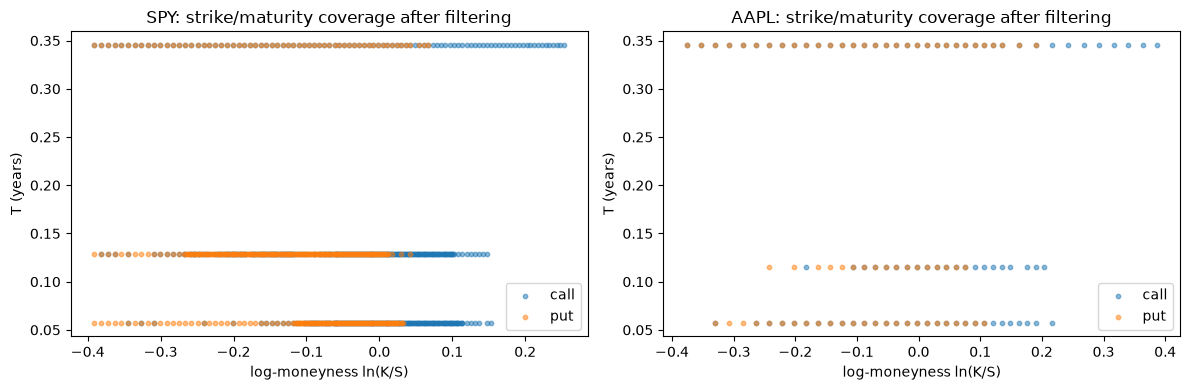

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [("SPY", spy_df), ("AAPL", aapl_df)]):
    for opt_type, grp in df.groupby("option_type"):
        ax.scatter(grp["log_moneyness"], grp["T_years"], s=10, alpha=0.5, label=opt_type)
    ax.set_xlabel("log-moneyness ln(K/S)")
    ax.set_ylabel("T (years)")
    ax.set_title(f"{name}: strike/maturity coverage after filtering")
    ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/eda_chain_coverage.png", dpi=120)
plt.show()

## Liquidity and bid-ask spread

In [7]:
for name, df in [("SPY", spy_df), ("AAPL", aapl_df)]:
    rel_spread = (df["ask"] - df["bid"]) / df["mid"]
    print(f"--- {name} ---")
    print("relative spread (ask-bid)/mid:")
    print(rel_spread.describe())
    print("open interest:")
    print(df["openInterest"].describe())
    print()

--- SPY ---
relative spread (ask-bid)/mid:
count    937.000000
mean       0.054571
std        0.089925
min        0.001695
25%        0.011765
50%        0.022472
75%        0.052486
max        0.666667
dtype: float64
open interest:
count       937.000000
mean       2760.817503
std       13855.677200
min          10.000000
25%         143.000000
50%         457.000000
75%        1527.000000
max      300905.000000
Name: openInterest, dtype: float64

--- AAPL ---
relative spread (ask-bid)/mid:
count    163.000000
mean       0.226003
std        0.406022
min        0.015649
25%        0.044064
50%        0.071146
75%        0.151505
max        1.833333
dtype: float64
open interest:
count      163.000000
mean      2840.852761
std       4653.213494
min         11.000000
25%        154.000000
50%        594.000000
75%       3804.000000
max      27341.000000
Name: openInterest, dtype: float64



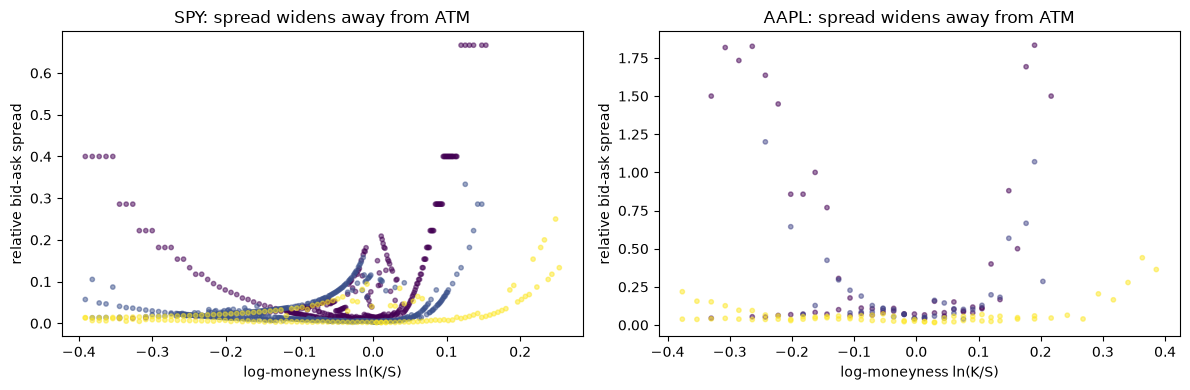

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df) in zip(axes, [("SPY", spy_df), ("AAPL", aapl_df)]):
    rel_spread = (df["ask"] - df["bid"]) / df["mid"]
    ax.scatter(df["log_moneyness"], rel_spread, s=10, alpha=0.5, c=df["T_years"], cmap="viridis")
    ax.set_xlabel("log-moneyness ln(K/S)")
    ax.set_ylabel("relative bid-ask spread")
    ax.set_title(f"{name}: spread widens away from ATM")
plt.tight_layout()
plt.savefig("../results/figures/eda_spread_vs_moneyness.png", dpi=120)
plt.show()

## A data-quality note: yfinance's own `impliedVolatility` field

The processed data carries yfinance's own implied-vol estimate
(`impliedVolatility`) as a reference column. It should **not** be treated as
ground truth — some values are implausibly close to zero even for options
with substantial extrinsic value, which is a sign the upstream solver failed
or defaulted rather than a real observation. This is exactly why the toolkit
implements its own Brent-based IV solver (`src/implied_vol.py`, notebook 03)
rather than trusting this field for H2/H4.

In [9]:
for name, df in [("SPY", spy_df), ("AAPL", aapl_df)]:
    n_suspect = (df["impliedVolatility"] < 0.01).sum()
    print(f"{name}: {n_suspect} of {len(df)} contracts have yfinance IV < 0.01 "
          f"({100*n_suspect/len(df):.1f}%) despite non-trivial mid prices")
    if n_suspect > 0:
        display(df[df["impliedVolatility"] < 0.01][
            ["expiry", "option_type", "strike", "bid", "ask", "mid", "impliedVolatility"]
        ].head(5))

SPY: 22 of 937 contracts have yfinance IV < 0.01 (2.3%) despite non-trivial mid prices


,expiry,option_type,strike,bid,ask,mid,impliedVolatility
333,2026-09-30,call,575.0,167.49,170.96,169.225,0.00001
336,2026-09-30,call,590.0,152.85,156.32,154.585,0.00001
339,2026-09-30,call,599.0,144.10,147.57,145.835,0.00001
341,2026-09-30,call,601.0,158.28,161.67,159.975,0.00001
346,2026-09-30,call,609.0,137.98,141.49,139.735,0.00001


AAPL: 0 of 163 contracts have yfinance IV < 0.01 (0.0%) despite non-trivial mid prices


## Summary

- Both SPY and AAPL chains pulled cleanly across three expiry buckets (near/mid/long).
- Filtering removes a meaningful share of contracts (see table above), mostly
  from the open-interest and extreme-moneyness gates — this is expected and
  intentional, not a data problem.
- yfinance's bundled `impliedVolatility` field is unreliable at the tails;
  the toolkit computes its own IV from mid prices going forward.
- Next: implement and unit-test the Black-Scholes closed form (notebook n/a,
  see `tests/`), then binomial and Monte Carlo convergence (notebook 02).